# Train LARD
Train a simple runway classifier (runway / no runway) on the LARD dataset.

## Dataset

In [1]:
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from vnn.datasets import LARD

# Add some data augmentation for to try to add some robustness to the model
size = 32
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomApply(
            [
                v2.RandomChoice(
                    [
                        v2.RandomRotation(degrees=10),
                        v2.RandomAffine(
                            degrees=(0, 0), translate=(0.1, 0.2), scale=(1.0, 1.0)
                        ),
                        v2.RandomPerspective(distortion_scale=0.2, p=0.5),
                    ]
                )
            ],
            p=0.2,
        ),
        v2.Resize((size, size)),
        v2.ToDtype(torch.float32, scale=True),
    ]
)
train_dataset = LARD(size=size, split="train", transform=transform)
val_dataset = LARD(size=size, split="val")

train_dataloader = DataLoader(
    train_dataset, shuffle=True, batch_size=128, num_workers=16
)
val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=128, num_workers=16)

print(f"Training: {len(train_dataset):,d} samples, {len(train_dataloader)} batches")
print(f"Validation: {len(val_dataset):,d} samples, {len(val_dataloader)} batches")

Training: 4,765 samples, 38 batches
Validation: 1,292 samples, 11 batches


### Visualize one batch

In [2]:
images, labels = next(iter(train_dataloader))

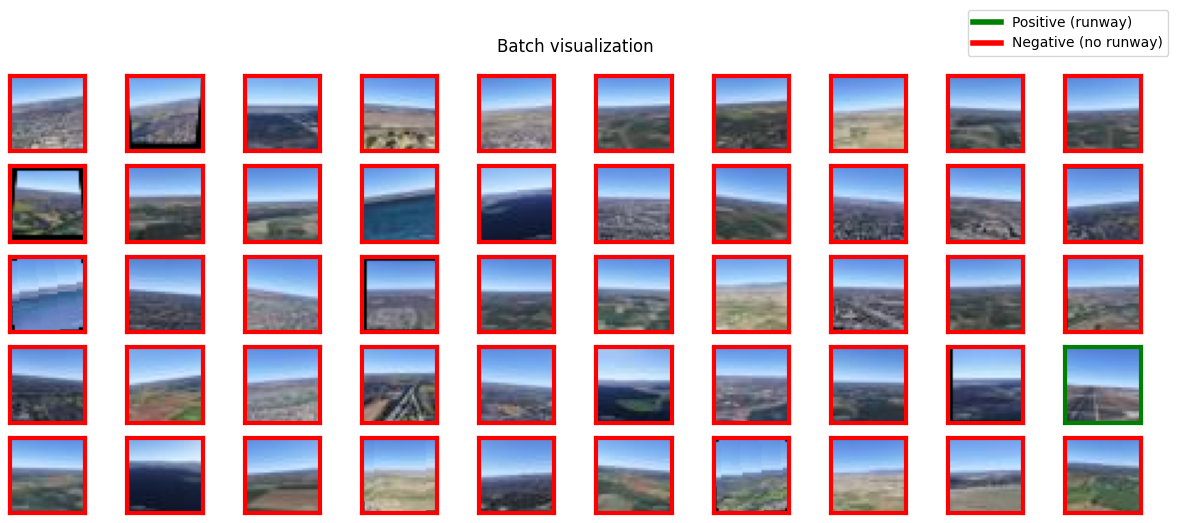

In [3]:
import matplotlib.pyplot as plt


def plot_batch(images, labels, predicted_labels=None):
    num_cols = 10
    num_rows = len(labels) // num_cols + 1
    num_rows = min(num_rows, 5)  # Limit to 5 rows for better visualization

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows))
    axes = axes.flatten()

    if predicted_labels is None:
        predicted_labels = [None] * len(labels)

    def add_border(ax, color="black", border_width=2):
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(border_width)
            ax.set_xticks([])
            ax.set_yticks([])

    for img, label, pred, ax in zip(images, labels, predicted_labels, axes):
        ax.imshow(img.permute(1, 2, 0))  # Convert from CHW to HWC for visualization
        color = "green" if label == 1 else "red"
        add_border(ax, color=color, border_width=3)

        if pred is not None:
            ax.set_title(f"GT: {label.item()}, Pred: {pred}", fontsize=8)

    fig.legend(
        handles=[
            plt.Line2D([0], [0], color="green", lw=4, label="Positive (runway)"),
            plt.Line2D([0], [0], color="red", lw=4, label="Negative (no runway)"),
        ],
        loc="outside upper right",
        bbox_to_anchor=(1, 1.05),
    )

    plt.suptitle("Batch visualization")
    plt.tight_layout()
    plt.show()


plot_batch(images, labels)

## Model
VNN-COMP architecture obtained from https://github.com/oval-group/GNN_branching/tree/master/models

Other sources:
- https://github.com/VNN-COMP/vnncomp2021/tree/main/benchmarks/cifar10_resnet/onnx
- https://github.com/VNN-COMP/vnncomp2020/tree/master/2020/CNN/benchmark/cifar/oval

In [ ]:
import math
from torch import nn


def init_kaiming(model):
    """Apply Kaiming/He initialization to Conv2d layers."""
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            m.weight.data.normal_(0, math.sqrt(2.0 / n))
            m.bias.data.zero_()
    return model


def cifar_base_kw():
    return nn.Sequential(
        nn.Conv2d(3, 8, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(8, 16, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(16 * 8 * 8, 100),
        nn.ReLU(),
        nn.Linear(100, 10),
    )


def cifar_wide_kw():
    return nn.Sequential(
        nn.Conv2d(3, 16, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(16, 32, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(32 * 8 * 8, 100),
        nn.ReLU(),
        nn.Linear(100, 10),
    )


def cifar_deep_kw():
    return nn.Sequential(
        nn.Conv2d(3, 8, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(8, 8, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(8, 8, 3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(8, 8, 4, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(8 * 8 * 8, 100),
        nn.ReLU(),
        nn.Linear(100, 10),
    )


# def cifar_deep_kw():
#     model = nn.Sequential(
#         nn.Conv2d(3, 8, 4, stride=2, padding=1),
#         nn.ReLU(),
#         nn.Conv2d(8, 8, 3, stride=1, padding=1),
#         nn.ReLU(),
#         nn.Conv2d(8, 8, 3, stride=1, padding=1),
#         nn.ReLU(),
#         nn.Conv2d(8, 8, 4, stride=2, padding=1),
#         nn.ReLU(),
#         nn.Flatten(),
#         nn.Linear(8 * 8 * 8, 100),
#         nn.ReLU(),
#         nn.Linear(100, 2),
#     )

#     for m in model.modules():
#         if isinstance(m, nn.Conv2d):
#             n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
#             m.weight.data.normal_(0, math.sqrt(2.0 / n))
#             m.bias.data.zero_()

#     return model

In [5]:
import torch
import torch.nn.functional as F
from torch.fx import symbolic_trace
from torchinfo import summary


def count_total_relu_elements_fx(model, input_shape):
    class ReLUElementCounter(torch.fx.Interpreter):
        def __init__(self, module):
            super().__init__(module)
            self.total_elements = 0

        def call_function(self, target, args, kwargs):
            out = super().call_function(target, args, kwargs)
            if target == F.relu:
                if isinstance(out, torch.Tensor):
                    self.total_elements += out.numel()
            return out

        def call_method(self, target, args, kwargs):
            out = super().call_method(target, args, kwargs)
            if target == "relu":
                if isinstance(out, torch.Tensor):
                    self.total_elements += out.numel()
            return out

    traced = symbolic_trace(model)
    counter = ReLUElementCounter(traced)
    example_input = torch.zeros((1,) + input_shape).to(next(model.parameters()).device)
    counter.run(example_input)
    return counter.total_elements


def count_total_relu_elements_fx_all(model, input_shape):
    class ReLUElementCounter(torch.fx.Interpreter):
        def __init__(self, module):
            super().__init__(module)
            self.total_elements = 0

        def call_function(self, target, args, kwargs):
            out = super().call_function(target, args, kwargs)
            if target == F.relu:
                if isinstance(out, torch.Tensor):
                    self.total_elements += out.numel()
            return out

        def call_method(self, target, args, kwargs):
            out = super().call_method(target, args, kwargs)
            if target == "relu":
                if isinstance(out, torch.Tensor):
                    self.total_elements += out.numel()
            return out

        def call_module(self, target, args, kwargs):
            module = self.fetch_attr(target)
            out = super().call_module(target, args, kwargs)
            if isinstance(module, nn.ReLU):
                if isinstance(out, torch.Tensor):
                    self.total_elements += out.numel()
            return out

    traced = symbolic_trace(model)
    counter = ReLUElementCounter(traced)
    example_input = torch.zeros((1,) + input_shape).to(next(model.parameters()).device)
    counter.run(example_input)
    return counter.total_elements


params_model = {
    # "shape_in": (3,46,46),
    "shape_in": (3, 32, 32),
    "initial_filters": 8,
    "num_fc1": 100,
    "dropout_rate": 0.25,
    "num_classes": 2,
}

model = cifar_base_kw()
# model = cifar_deep_kw()
# model = cifar_wide_kw()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(summary(model, input_size=(1, *params_model["shape_in"])))
total_relu_elements = count_total_relu_elements_fx(model, params_model["shape_in"])
print(f"{total_relu_elements:,d} ReLU nodes")
total_relu_elements_all = count_total_relu_elements_fx_all(
    model, params_model["shape_in"]
)
print(f"{total_relu_elements_all:,d} ReLU nodes (including nn.ReLU modules)")

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 8, 16, 16]            392
├─ReLU: 1-2                              [1, 8, 16, 16]            --
├─Conv2d: 1-3                            [1, 16, 8, 8]             2,064
├─ReLU: 1-4                              [1, 16, 8, 8]             --
├─Flatten: 1-5                           [1, 1024]                 --
├─Linear: 1-6                            [1, 100]                  102,500
├─ReLU: 1-7                              [1, 100]                  --
├─Linear: 1-8                            [1, 10]                   1,010
Total params: 105,966
Trainable params: 105,966
Non-trainable params: 0
Total mult-adds (M): 0.34
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 0.42
Estimated Total Size (MB): 0.46
0 ReLU nodes
3,172 ReLU nodes (including nn.ReLU modules)


## Loss & Optimizer

In [6]:
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Try to address class imbalance with weights in the loss function
# loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([0.12, 0.88]), reduction="sum")
loss_fn = nn.CrossEntropyLoss(reduction="sum")
optimizer = optim.Adam(model.parameters(), lr=3e-4)
lr_scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=20)

## Training

In [7]:
def get_lr(opt):
    return opt.param_groups[0]["lr"]


def train_step(dataloader, model, loss_fn, optimizer):
    model.train()

    run_loss = 0.0
    t_metric = 0.0
    len_data = len(dataloader.dataset)

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        output = model(X)
        loss = loss_fn(output, y)  # Model output is already a log_softmax
        pred = output.argmax(dim=1, keepdim=True)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        run_loss += loss.item()
        t_metric += pred.eq(y.view_as(pred)).sum().item()

    loss = run_loss / float(len_data)
    metric = t_metric / float(len_data)

    return loss, metric


def val_step(dataloader, model, loss_fn):
    model.eval()

    run_loss = 0.0
    t_metric = 0.0
    len_data = len(dataloader.dataset)

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            output = model(X)
            loss = loss_fn(output, y)
            pred = output.argmax(dim=1, keepdim=True)

            run_loss += loss.item()

            # TODO(jgd) Revisit this
            t_metric += pred.eq(y.view_as(pred)).sum().item()

    loss = run_loss / float(len_data)
    metric = t_metric / float(len_data)

    return loss, metric

### Training Loop

In [8]:
import copy
from tqdm.notebook import tqdm

num_epochs = 100
weight_path = "model.pt"

loss_history = {"train": [], "val": []}
metric_history = {"train": [], "val": []}
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float("inf")
last_lr = get_lr(optimizer)

for epoch in tqdm(range(1, num_epochs + 1)):
    train_loss, train_metric = train_step(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_metric = val_step(val_dataloader, model, loss_fn)
    lr_scheduler.step(val_loss)

    print(
        f"Epoch {epoch}/{num_epochs}: train loss={train_loss:.6f} val loss={val_loss:.6f} val accuracy={100 * val_metric:.2f} (lr={last_lr:.6f})"
    )

    if val_loss < best_loss:
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), weight_path)
        best_loss = val_loss

    loss_history["train"].append(train_loss)
    metric_history["train"].append(train_metric)
    loss_history["val"].append(val_loss)
    metric_history["val"].append(val_metric)

    # Restart from best model if learning rate changes
    current_lr = get_lr(optimizer)
    if current_lr != last_lr:
        model.load_state_dict(best_model_wts)
        last_lr = current_lr

model.load_state_dict(best_model_wts)

# Save to ONNX
example_inputs = (torch.randn(1, *params_model["shape_in"], device=device),)
torch.onnx.export(model, example_inputs, "model.onnx")

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100: train loss=1.226185 val loss=0.443572 val accuracy=89.01 (lr=0.000300)
Epoch 2/100: train loss=0.373046 val loss=0.349567 val accuracy=89.01 (lr=0.000300)
Epoch 3/100: train loss=0.334897 val loss=0.328698 val accuracy=89.01 (lr=0.000300)
Epoch 4/100: train loss=0.292734 val loss=0.312585 val accuracy=89.01 (lr=0.000300)
Epoch 5/100: train loss=0.254570 val loss=0.271458 val accuracy=90.17 (lr=0.000300)
Epoch 6/100: train loss=0.240476 val loss=0.247577 val accuracy=90.40 (lr=0.000300)
Epoch 7/100: train loss=0.208699 val loss=0.263679 val accuracy=89.94 (lr=0.000300)
Epoch 8/100: train loss=0.197795 val loss=0.205589 val accuracy=91.87 (lr=0.000300)
Epoch 9/100: train loss=0.197335 val loss=0.213084 val accuracy=91.18 (lr=0.000300)
Epoch 10/100: train loss=0.177855 val loss=0.189478 val accuracy=92.26 (lr=0.000300)
Epoch 11/100: train loss=0.170561 val loss=0.185573 val accuracy=92.26 (lr=0.000300)
Epoch 12/100: train loss=0.162687 val loss=0.163603 val accuracy=92.88 (lr

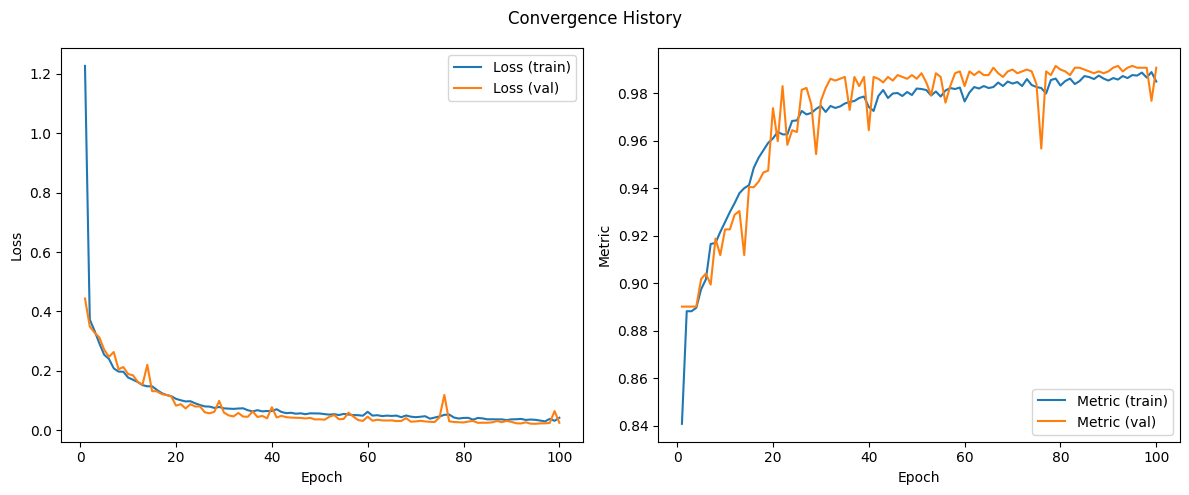

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(range(1, num_epochs + 1), loss_history["train"], label="Loss (train)")
ax[0].plot(range(1, num_epochs + 1), loss_history["val"], label="Loss (val)")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(range(1, num_epochs + 1), metric_history["train"], label="Metric (train)")
ax[1].plot(range(1, num_epochs + 1), metric_history["val"], label="Metric (val)")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Metric")
ax[1].legend()

fig.suptitle("Convergence History")
plt.tight_layout()
plt.show()

## Test set evaluation

In [10]:
import numpy as np

dataset_test = LARD(size=32, split="test")
test_dl = DataLoader(dataset_test, shuffle=False, batch_size=128, num_workers=16)
print(f"Test: {len(dataset_test):,d} samples, {len(test_dl)} batches")

images, labels = next(iter(test_dl))

# Compute predictions on the test set
y = []
y_hat_scores = []
y_hat = []

model.eval()
with torch.no_grad():
    for Xb, yb in test_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        probabilities = F.softmax(logits, dim=1)
        pred = probabilities.argmax(dim=1)  # Get predicted class

        y.extend(yb.cpu().numpy())
        y_hat_scores.extend(probabilities[:, 1].cpu().numpy())
        y_hat.extend(pred.cpu().numpy())

y = np.array(y)
y_hat = np.array(y_hat)
y_hat_scores = np.array(y_hat_scores)

Test: 656 samples, 6 batches


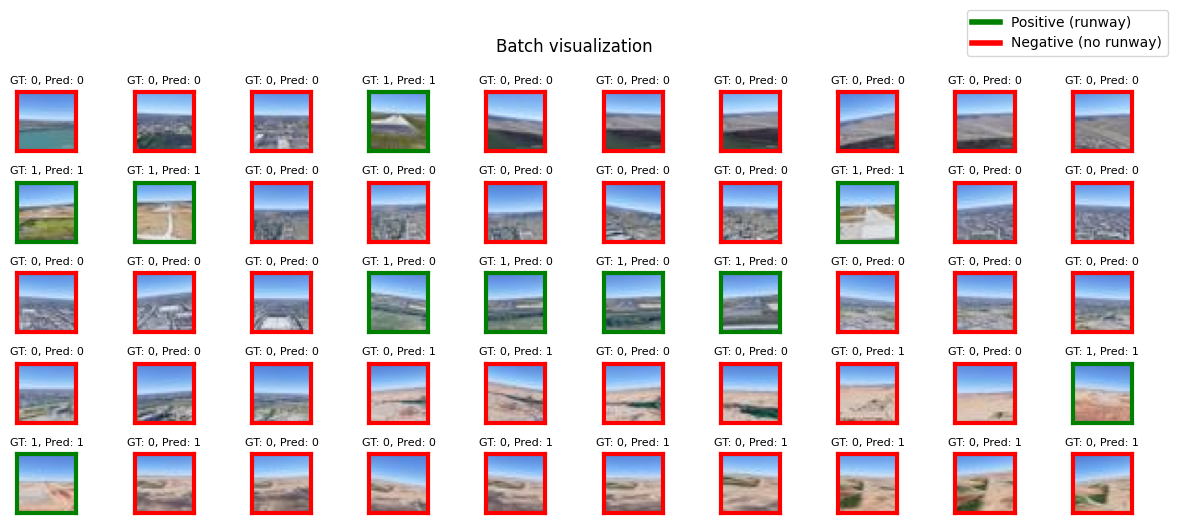

In [11]:
plot_batch(images, labels, y_hat)

### Finetuning the classifier

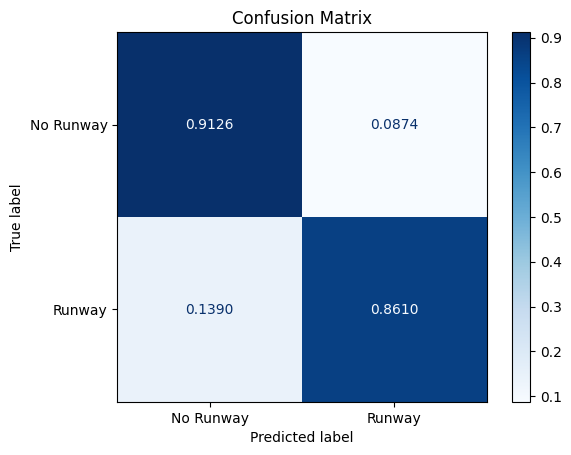

True Positives: 161
False Positives: 41
True Negatives: 428
False Negatives: 26
Accuracy: 89.79%


In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_normalized = confusion_matrix(y, y_hat, normalize="true")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized, display_labels=["No Runway", "Runway"]
)
disp.plot(cmap="Blues", values_format=".4f")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives: {tn}")
print(f"False Negatives: {fn}")

accuracy = (tp + tn) / (tp + fp + tn + fn)
print(f"Accuracy: {100 * accuracy:.2f}%")

In [13]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y, y_hat_scores)
roc_auc = auc(fpr, tpr)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines",
        name=f"ROC Curve (AUC = {roc_auc:.3f})",
        text=[f"Threshold: {thresh:.6f}" for thresh in thresholds],
        hovertemplate="FPR: %{x:.6f}<br>TPR: %{y:.6f}<br>%{text}<extra></extra>",
    )
)

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Chance",
        line=dict(dash="dash", color="gray"),
    )
)

fig.update_layout(
    title="ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    hovermode="x unified",
)

fig.show()

In [14]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=tpr, mode="lines", name="TPR"))
fig.add_trace(go.Scatter(x=thresholds, y=fpr, mode="lines", name="FPR"))

fig.update_layout(
    title="TPR and FPR as a Function of Decision Threshold",
    xaxis_title="Decision Threshold",
    yaxis_title="Rate",
    hovermode="x unified",
)
fig.show()

## Save instances for bounds calculation
We save 100 balanced indices from the test set where predictions are correct.

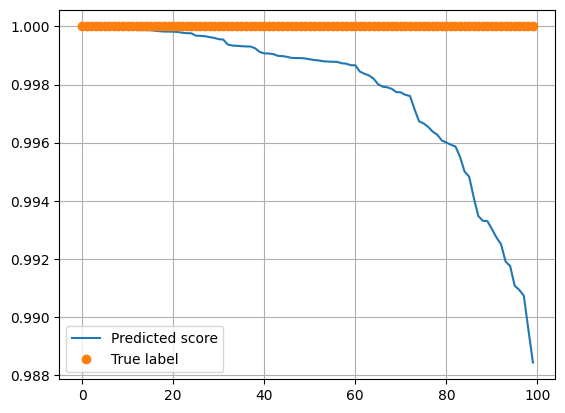

In [17]:
import pandas as pd

# We sort by confidence, in the hope that it somewhat translates to robustness and/or will be comparable between models.
idx_sorted = np.argsort(y_hat_scores)[::-1]

idx_positive = idx_sorted[y[idx_sorted] == 1][:100]  # Highest scores
idx_negative = []  # idx_sorted[y[idx_sorted] == 0][:50]
idx_selected = np.concatenate([idx_positive, idx_negative]).astype(int)

plt.figure()
plt.plot(y_hat_scores[idx_selected], label="Predicted score")
plt.plot(y[idx_selected], "o", label="True label")
plt.legend()
plt.grid()
plt.show()

# Save the selected indices to a CSV file
df_selected = pd.DataFrame({"index": idx_selected})
df_selected.to_csv("instances.csv", index=False, header=False)

# Get the associated metadata for additional checks
df_dataset = pd.read_csv(LARD.PATH_CSV, sep=";")
df_test = df_dataset[df_dataset["split"] == "test"].reset_index(drop=True)
df_selected = df_test.iloc[idx_selected].copy()
df_selected.insert(0, "index", idx_selected)
df_selected.to_csv("instances_full.csv", index=False)

In [22]:
idx_selected

array([  3,  10,  11,  17,  50,  56,  57,  58,  61,  70,  71,  72,  73,
        75,  87, 118, 119, 120, 131, 132, 133, 160, 161, 171, 176, 181,
       185, 186, 189, 190, 206, 216, 276, 277, 289, 290, 291, 292, 293,
       308, 323, 324, 325, 335, 336, 337, 348, 351, 352, 360, 376, 386,
       387, 394, 395, 396, 397, 402, 403, 483, 494, 495, 496, 509, 510,
       519, 523, 543, 544, 552, 553, 554, 555, 556, 571, 572, 578, 579,
       580, 581, 582, 583, 584, 585, 586, 587, 594, 602, 603, 604, 609,
       610, 611, 616, 617, 628, 639, 650, 651, 653])